In [78]:
from datetime import datetime
import numpy as np
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

rng = np.random.default_rng() # To generate random numbers
options={"disp": False} # To not get verbose from minimize function

In [79]:
def sig(z):
    """ Sigmoid function """
    return 1 / (1 + np.exp(-z))

In [80]:
# NOTE TO DO : put in general algorithm function that if radius == NA then this is not done.
def project_onto_l2_ball(x,radius):
    """ Euclidean projection onto L2 ball"""
    norm = np.linalg.norm(x)
    if norm <= radius:
        return x
    return x * radius/norm

In [81]:
# Define function to minimize for AIOLI
def old_parameter_function_AIOLI(b, xt, betas, etas, reg_lambda, sum_loss,gradients):
    diff = b - betas # this subtracts b from each row of the matrix of betas. meaning to each set of betas from s = 1 to t-1
    gs_bs = np.sum(gradients * diff,axis = 1) # axis 1 ensures to get a row-wise dot product, meaning multiply each gradient with its corresponding betas.
    quadratic = np.sum(np.sum(etas)/2 * gs_bs**2)

    l_hat = sum_loss + np.sum(gs_bs) + quadratic
    # Use function np.logaddexp = log(exp(x1) + exp(x2)) to ensure numerical stability, not sure how it works
    result = l_hat + np.logaddexp(0,np.inner(b,xt)) + np.logaddexp(0,np.inner(-b,xt)) + reg_lambda*np.linalg.norm(b)
    return result

In [82]:
#(improved)
# Define function to minimize for AIOLI
def parameter_function_AIOLI(b, xt, reg_lambda, sum_loss, first_sum, etas_gradients):
    l_hat = sum_loss + np.inner(b,first_sum) + np.inner(np.inner(b,etas_gradients), b)
    # Use function np.logaddexp = log(exp(x1) + exp(x2)) to ensure numerical stability, not sure how it works
    result = l_hat + np.logaddexp(0,np.inner(b,xt)) + np.logaddexp(0,np.inner(-b,xt)) + reg_lambda*np.linalg.norm(b)
    return result

Online Gradient Descent

In [83]:
def online_gd(n, d, data_y, data_x, eta, B):
    """Online gradient descent
    Parameters
    ---------
    n : float
        Size of the dataset
    d : float
        Dimension of the context vector, i.e. number of independent variables
    data_y : ndarray
        Vector with outcome(y) values. Dimensions: n x 1
    data_x: ndarray
        Array with independent variables. Dimensions: n x d
    eta: float
        Learning rate.
    B: float
        Radius of the L2 ball constraint for the parameter vector beta"""

    # Start time
    start_time = datetime.now()

    # Initialize vectors
    betas = np.zeros((n,d)) # Parameter vector of all n rounds.
    gradient =  np.zeros((n,d)) # Gradient: g_t
    gradients_sum = np.zeros(d) # Gradient sum: g_s from s=1 to t - 1 (it gets updated at the end of the round)
    loss = np.zeros(n)

    for t in range(n):
        # Observe context vector for this round
        xt = data_x[t]

        # Update parameter (beta)
        if t == 0:
            beta_tilde = np.zeros(d)
        else:
            beta_tilde = -eta * gradients_sum

        # Euclidean projection of beta onto the L2 ball
        betas[t] = project_onto_l2_ball(beta_tilde,B)

        # Issue prediction
        #y_hat = sig(np.inner(betas[t],xt)) commented out because its never used so there's no need to calculate it

        # Observe true y from the data
        yt = data_y[t]

        # Calculate gradient and sum of gradients
        gradient = -yt*xt*sig(-yt*np.inner(xt,betas[t]))
        gradients_sum += gradient

        # Suffer loss
        loss[t] = np.log(1+np.exp(-yt*np.inner(xt,betas[t])))

    # Store endtime
    end_time = datetime.now()
    return{
        "runtime" : (end_time - start_time).total_seconds(),
        "Total_Loss" : sum(loss)
    }


AIOLI

In [126]:
def AIOLI(n, d, data_y, data_x, B, X):
    """AIOLI
    Parameters
    ---------
    n : float
        Size of the dataset
    d : float
        Dimension of the context vector, i.e. number of independent variables
    data_y : ndarray
        Vector with outcome(y) values. Dimensions: n x 1
    data_x: ndarray
        Array with independent variables. Dimensions: n x d
    B: float
        Radius of the L2 ball constraint for the parameter vector beta
    X: float
        Radius of the L2 ball constraint for the feature vector x"""
    # Record start time
    start_time = datetime.now()

    # Initialize vectors for storage
    betas = np.zeros((n, d))
    ys = np.zeros(n)
    y_hats = np.zeros(n)
    loss = np.zeros(n)
    etas = np.zeros(n)
    gradients = np.zeros((n, d))
    sum_loss = 0
    reg_lambda = 1 / (B**2)

    # Keep sums for loss functions
    gradients_sum = 0
    first_sum  = 0
    etas_gradients = 0

    # Run Algorithm
    for t in range(n):
        # Get context vector
        xt = data_x[t]

        # Update beta parameter
        if t == 0: # Initialize to 0 for first round
            beta_tilde = np.zeros(d)
        else:
            x0 = np.zeros(d) # Random initializer for minimizing algorithm, Completely arbitrary for now
            beta_tilde = minimize(parameter_function_AIOLI, x0, method = "L-BFGS-B", args=(xt, reg_lambda, sum_loss,first_sum, etas_gradients)).x # Note here doing betas[:t] takes all up to but NOT including t.

        # Project beta onto set
        betas[t] = project_onto_l2_ball(beta_tilde,B)

        # Generate prediction
        y_hats[t] = np.inner(betas[t],xt)

        # Observe true y from data
        ys[t] = data_y[t]

        # Estimate eta
        etas[t] = np.exp(ys[t]*y_hats[t])/(1+B*X)

        # Compute gradient
        gradients[t] = -ys[t]*xt*sig(-ys[t]*np.inner(xt,betas[t]))

        gradients_sum += gradients[t]
        first_sum += gradients[t]*(1 - etas[t]*np.inner(betas[t],gradients[t]))
        etas_gradients += (etas[t]/2)*np.inner(gradients[t],gradients[t])

        # Suffer loss
        loss[t] = np.log(1+np.exp(-ys[t]*np.inner(xt,betas[t])))

        # Update sum of losses
        sum_loss += loss[t]
    # for loop ends

    end_time = datetime.now()
    return{
        "runtime" : (end_time - start_time).total_seconds(),
        "Total_Loss" : sum_loss
    }


In [116]:
def old_AIOLI(n, d, data_y, data_x, B, X):
    """AIOLI
    Parameters
    ---------
    n : float
        Size of the dataset
    d : float
        Dimension of the context vector, i.e. number of independent variables
    data_y : ndarray
        Vector with outcome(y) values. Dimensions: n x 1
    data_x: ndarray
        Array with independent variables. Dimensions: n x d
    B: float
        Radius of the L2 ball constraint for the parameter vector beta
    X: float
        Radius of the L2 ball constraint for the feature vector x"""
    # Record start time
    start_time = datetime.now()

    # Initialize vectors for storage
    betas = np.zeros((n, d))
    ys = np.zeros(n)
    y_hats = np.zeros(n)
    loss = np.zeros(n)
    etas = np.zeros(n)
    gradients = np.zeros((n, d))
    sum_loss = 0
    reg_lambda = 1 / (B**2)

    # Run Algorithm
    for t in range(n):
        # Get context vector
        xt = data_x[t]

        # Update beta parameter
        if t == 0: # Initialize to 0 for first round
            beta_tilde = np.zeros(d)
        else:
            x0 = np.zeros(d) # Random initializer for minimizing algorithm, Completely arbitrary for now
            beta_tilde = minimize(old_parameter_function_AIOLI, x0, method = "L-BFGS-B", args=(xt, betas[:t], etas[:t], reg_lambda, sum_loss,gradients[:t])).x # Note here doing betas[:t] takes all up to but NOT including t.

        # Project beta onto set
        betas[t] = project_onto_l2_ball(beta_tilde,B)

        # Generate prediction
        y_hats[t] = np.inner(betas[t],xt)

        # Observe true y from data
        ys[t] = data_y[t]

        # Estimate eta
        etas[t] = np.exp(ys[t]*y_hats[t])/(1+B*X)

        # Compute gradient
        gradients[t] = -ys[t]*xt*sig(-ys[t]*np.inner(xt,betas[t]))

        # Suffer loss
        loss[t] = np.log(1+np.exp(-ys[t]*np.inner(xt,betas[t])))

        # Update sum of losses
        sum_loss += loss[t]
    # for loop ends

    end_time = datetime.now()
    return{
        "runtime" : (end_time - start_time).total_seconds(),
        "Total_Loss" : sum_loss
    }


Tests

In [85]:
etas = np.array([1/np.sqrt(3),1/np.sqrt(3),1/np.sqrt(3)])
xt = np.array([1,2,3])
betas = np.array([[2,2,5],[1,1,3],[4,5,6]])
reg_lambda = 0.3
gradients = np.array([[2,2,5],[1,1,3],[4,5,6]])
b = np.array([1,2,3])
sum_loss = 5


#(sum(etas)/2)*np.inner((b-betas[2]),gradients[2])*np.inner(gradients[2],(b-betas[2]))
#np.linalg.norm(etas)


In [86]:
diff = b - betas
inner_prod = np.sum(gradients * diff,axis = 1)
np.sum(np.sum(etas)/2 * inner_prod**2)

np.float64(1879.2751262122324)

In [87]:
x0 = np.array([0,0,0])

#res = minimize(parameter_function_AIOLI, x0, method = "L-BFGS-B", args=(xt, reg_lambda, sum_loss,first_sum, etas_gradients))
#parameter_function_AIOLI(x0, xt, betas, etas, reg_lambda, sum_loss,gradients)
#res.x

In [88]:
diff = b - betas
gs_bs = np.sum(gradients * diff,axis = 1)
quadratic = np.sum(np.sum(etas)/2 * gs_bs**2)

l_hat = sum_loss + np.sum(gs_bs) + quadratic

l_hat + np.log(1+np.exp(np.inner(b,xt))) + np.log(1+np.exp(np.inner(-b,xt))) + reg_lambda*np.linalg.norm(b)

np.float64(1843.397625091321)

# Testing algorithm functions

## Generate data

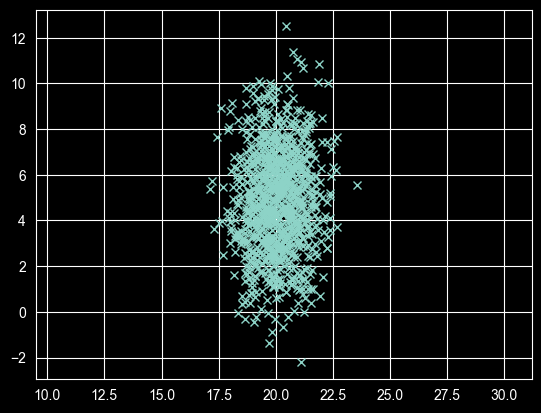

In [120]:
n = 1000

mean = [20, 5]
cov = [[1, 0], [0, 5]]  # diagonal covariance
y = np.random.binomial(n=1, p=0.3, size=n)

x1, x2 = np.random.multivariate_normal(mean, cov, size = n).T
plt.plot(x1, x2, 'x')
plt.axis('equal')
plt.show()

In [121]:
x = np.random.multivariate_normal(mean, cov, size = n)

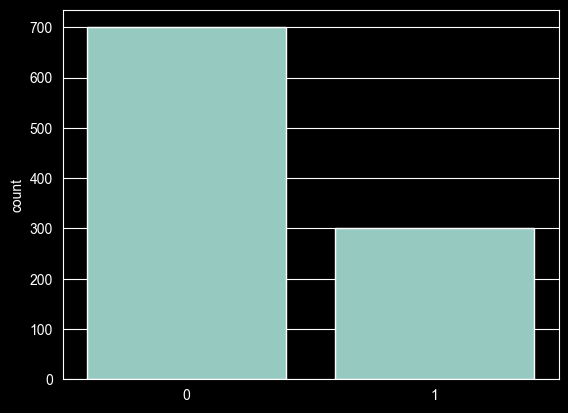

In [122]:
sns.countplot(x=y)
plt.show()


## Test OGD

In [124]:
results_ogd = online_gd(n = n,d = 2,data_y = y,data_x = x,eta = 0.2,B = 30)
results_aioli = AIOLI(n = n,d = 2,data_y = y,data_x = x, B = 30, X = 35)
results_aioli_old = old_AIOLI(n = n,d = 2,data_y = y,data_x = x, B = 30, X = 35)

In [125]:
results_all = pd.DataFrame([
    {
        "Algorithm": "OGD",
        "Runtime (seconds)": results_ogd["runtime"],
        "Total Loss": results_ogd["Total_Loss"]
    },
    {
        "Algorithm": "AIOLI",
        "Runtime (seconds)": results_aioli["runtime"],
        "Total Loss": results_aioli["Total_Loss"]
    },
    {
        "Algorithm": "OLD AIOLI",
        "Runtime (seconds)": results_aioli_old["runtime"],
        "Total Loss": results_aioli_old["Total_Loss"]
    }
])

results_all

,Algorithm,Runtime (seconds),Total Loss
0,OGD,0.033647,485.896174
1,AIOLI,4.155302,486.582843
2,OLD AIOLI,3.183611,691.501101
